# Урок 15.1. Функция и её график

**Интерактивная версия:** `lessons/lesson_15_1/web/index.html`

Первый урок главы «Математика под микроскопом». Начинаем с самого нуля и доходим до функций,
из которых собран градиентный бустинг. Пять блоков:

1. **Что такое функция**: правило «вход → выход», способы задания, координатная плоскость, график.
2. **Как читать график**: область определения и значений, нули и знаки, рост и экстремумы
   (max и argmax), уравнения по графику, чётность, период, асимптоты.
3. **Главные семейства**: прямая, парабола, зоопарк функций, сдвиги и растяжения, кусочные функции.
4. **Действия с функциями**: сумма (и бустинг как сумма ступенек), композиция, обратная функция,
   функции двух переменных.
5. **Функции в ML**: модель и потери как функции, честное чтение графиков (масштаб осей).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation

from gbcourse import datasets
from gbcourse.plotting import use_course_style
from gbcourse.style import AQUA, BLUE, INK, MUTED, ORANGE, RED

use_course_style()
plt.rcParams["animation.embed_limit"] = 30


def axes_cross(ax):
    """Оси координат через начало: тонкие линии x = 0 и y = 0."""
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.axvline(0, color=MUTED, lw=0.8)

## 1. Функция — машинка

Правило: каждому допустимому входу — **ровно один** выход. Такси: посадка 100 ₽ и 25 ₽ за километр.

In [2]:
def taxi(km):
    """Стоимость поездки в рублях."""
    return 100 + 25 * km


for km in [0, 1, 4, 10]:
    print(f"{km:3d} км → {taxi(km)} ₽")

  0 км → 100 ₽
  1 км → 125 ₽
  4 км → 200 ₽
 10 км → 350 ₽


**Подстановка.** В $f(x) = x^2 - 3x$ вместо *каждого* $x$ ставим подставляемое — в скобках.
Проверим $f(a + 1) = a^2 - a - 2$ и увидим, что $f(2x) \ne 2f(x)$.

In [3]:
f = lambda x: x**2 - 3 * x  # noqa: E731
print("f(0) =", f(0), " f(2) =", f(2), " f(-1) =", f(-1))
print("f(a+1) == a² − a − 2 для a = −5…5:", all(f(a + 1) == a**2 - a - 2 for a in range(-5, 6)))
print("f(2·3) =", f(6), " а 2·f(3) =", 2 * f(3))

f(0) = 0  f(2) = -2  f(-1) = 4
f(a+1) == a² − a − 2 для a = −5…5: True
f(2·3) = 18  а 2·f(3) = 0


**Приращение — взгляд вперёд.** Для $x^2$: $\dfrac{f(x+h) - f(x)}{h} = 2x + h$. При маленьком $h$
это почти $2x$ — будущая производная (урок 15.5).

In [4]:
sq = lambda x: x**2  # noqa: E731
for h in [1, 0.1, 0.01, 0.001]:
    print(f"h = {h:6}: (f(3 + h) − f(3)) / h = {(sq(3 + h) - sq(3)) / h:.4f}")

h =      1: (f(3 + h) − f(3)) / h = 7.0000
h =    0.1: (f(3 + h) − f(3)) / h = 6.1000
h =   0.01: (f(3 + h) − f(3)) / h = 6.0100
h =  0.001: (f(3 + h) − f(3)) / h = 6.0010


## 2. Четыре способа задать функцию

Словами, формулой, таблицей, графиком — и алгоритмом. Данные почти всегда приходят **таблицей**,
а модель машинного обучения задана **алгоритмом**.

In [5]:
hours = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24])
temps = np.array([9.6, 8.1, 10.2, 13.8, 18.5, 19.7, 18.0, 14.3, 9.9])
table = dict(zip(hours.tolist(), temps.tolist()))   # функция-таблица
print("в 9:00 измерено", table[9], "°C; в 10:30 — только оценка:", np.interp(10.5, hours, temps).round(2))


def tree(area):
    """Модель-алгоритм: дерево с одним вопросом (площадь в десятках м²)."""
    return 3 if area <= 3.5 else 9


print("дерево:", [tree(a) for a in [1, 3, 3.5, 4, 6]])

в 9:00 измерено 13.8 °C; в 10:30 — только оценка: 16.15
дерево: [3, 3, 3, 9, 9]


## 3. От таблицы к графику

Каждая пара $(x, f(x))$ — точка на координатной плоскости. Чем больше точек, тем лучше видна линия.
Но редкая таблица может обмануть: по 5 точкам $\sin 4x$ выглядит почти прямой.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


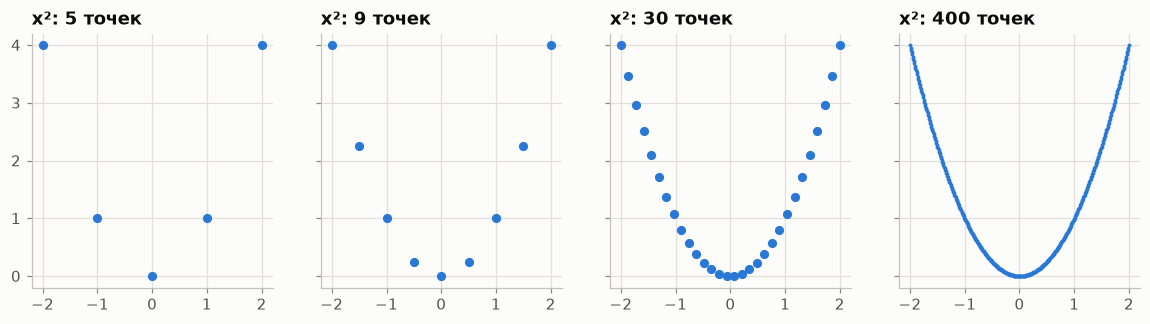

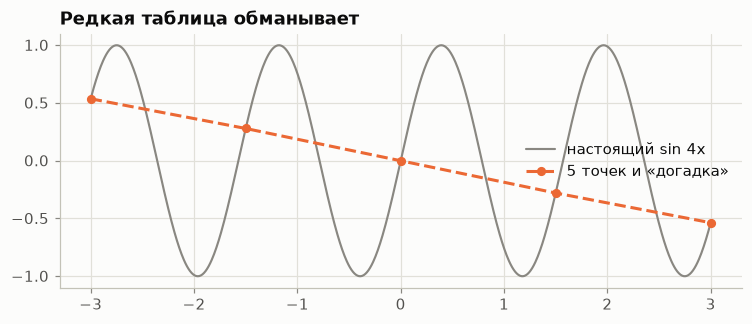

значения в 5 точках: [ 0.537  0.279  0.    -0.279 -0.537]


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True)
for ax, n in zip(axes, [5, 9, 30, 400]):
    x = np.linspace(-2, 2, n)
    ax.plot(x, x**2, "o", color=BLUE, ms=5 if n < 100 else 1.5)
    ax.set_title(f"x²: {n} точек")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
fine = np.linspace(-3, 3, 800)
x5 = np.linspace(-3, 3, 5)
ax.plot(fine, np.sin(4 * fine), color=MUTED, lw=1.4, label="настоящий sin 4x")
ax.plot(x5, np.sin(4 * x5), "o--", color=ORANGE, label="5 точек и «догадка»")
ax.legend()
ax.set_title("Редкая таблица обманывает")
plt.show()
print("значения в 5 точках:", np.sin(4 * x5).round(3))

### Анимация: точки сливаются в линию

In [7]:
counts = [3, 5, 8, 12, 20, 35, 60, 100, 200, 400]
fig, ax = plt.subplots(figsize=(6.5, 3.4), dpi=72)
dots, = ax.plot([], [], "o", color=BLUE)
ax.set(xlim=(-6.5, 6.5), ylim=(-1.3, 1.3), xlabel="x", ylabel="sin x")
title = ax.set_title("")


def frame(i):
    n = counts[i]
    x = np.linspace(-6.3, 6.3, n)
    dots.set_data(x, np.sin(x))
    dots.set_markersize(6 if n <= 20 else 3 if n <= 100 else 1.5)
    title.set_text(f"{n} точек")
    return dots, title


anim = animation.FuncAnimation(fig, frame, frames=len(counts), interval=600)
plt.close(fig)
display(HTML(anim.to_jshtml()))

**Вертикальный тест.** Окружность — не график функции: над одним $x$ две точки.

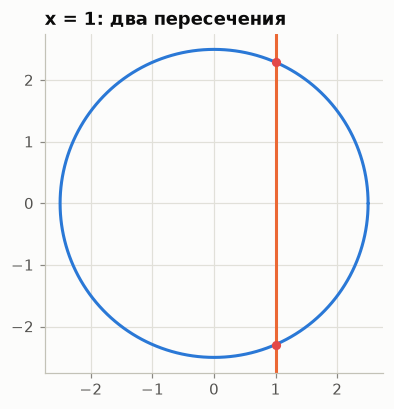

In [8]:
t = np.linspace(0, 2 * np.pi, 361)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(2.5 * np.cos(t), 2.5 * np.sin(t), color=BLUE, lw=2)
ax.axvline(1, color=ORANGE)
ax.plot([1, 1], [np.sqrt(6.25 - 1), -np.sqrt(6.25 - 1)], "o", color=RED)
ax.set_aspect("equal")
ax.set_title("x = 1: два пересечения")
plt.show()

## 4. Область определения и область значений

Три запрета: знаменатель $\ne 0$, под корнем $\ge 0$, под логарифмом $> 0$. numpy за пределами
области выдаёт `inf` или `nan` (не число) и предупреждение.

In [9]:
with np.errstate(all="ignore"):
    x = np.array([-1.0, 0.0, 4.0])
    print("1/x   :", 1 / x)
    print("sqrt x:", np.sqrt(x))
    print("ln x  :", np.log(x))

1/x   : [-1.     inf  0.25]
sqrt x: [nan  0.  2.]
ln x  : [       nan       -inf 1.38629436]


In [10]:
grid = np.round(np.linspace(-5, 5, 100001), 6)   # сетка проходит через целые точки


def bad_runs(x, ok):
    """Участки сетки, где функция не определена, — как список отрезков [a; b]."""
    runs, start, prev = [], None, None
    for xi, good in zip(x, ok):
        if not good and start is None:
            start = xi
        if good and start is not None:
            runs.append((start, prev))
            start = None
        prev = xi
    if start is not None:
        runs.append((start, prev))
    return ["{" + f"{a:g}" + "}" if a == b else f"[{a:g}; {b:g}]" for a, b in runs]


with np.errstate(all="ignore"):
    examples = {
        "1/(x − 2)": 1 / (grid - 2),
        "√(x + 3)": np.sqrt(grid + 3),
        "ln(5 − x)": np.log(5 - grid),
        "√x / (x − 4)": np.sqrt(grid) / (grid - 4),
        "ln(x² − 1)": np.log(grid**2 - 1),
        "1 / √(9 − x²)": 1 / np.sqrt(9 - grid**2),
    }
for name, y in examples.items():
    print(f"{name:14s} на [−5; 5] не определена: {', '.join(bad_runs(grid, np.isfinite(y)))}")

1/(x − 2)      на [−5; 5] не определена: {2}
√(x + 3)       на [−5; 5] не определена: [-5; -3.0001]
ln(5 − x)      на [−5; 5] не определена: {5}
√x / (x − 4)   на [−5; 5] не определена: [-5; -0.0001], {4}
ln(x² − 1)     на [−5; 5] не определена: [-1; 1]
1 / √(9 − x²)  на [−5; 5] не определена: [-5; -3], [3; 5]


**Область значений** — «тень» графика на оси $y$. Проверим по сетке: $x^2 + 3 \ge 3$, $5 - e^x < 5$,
$0 < \sigma(x) < 1$.

In [11]:
x = np.linspace(-10, 10, 200001)
sig = 1 / (1 + np.exp(-x))
print("x² + 3:", (x**2 + 3).min())
print("5 − eˣ: max =", (5 - np.exp(x)).max().round(6), "(5 не достигается)")
print("σ(x): от", sig.min().round(6), "до", sig.max().round(6))

x² + 3: 3.0
5 − eˣ: max = 4.999955 (5 не достигается)
σ(x): от 4.5e-05 до 0.999955


## 5. Читаем график: значения, рост и убывание

$T(t) = 14 - 6\cos\big(2\pi (t - 3)/24\big)$: минимум в 3:00, максимум в 15:00.

максимум 20.0 °C в 15:00, минимум 8.0 °C в 3:00
растёт с 3.01 до 15.00 ч
обратное чтение: 14 °C в [ 9. 21.] ч


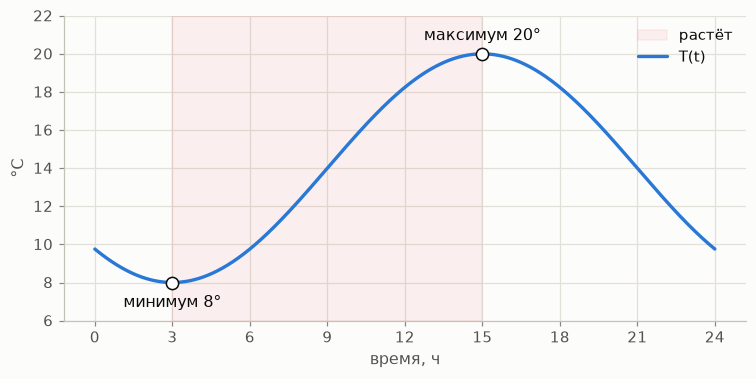

In [12]:
T = lambda h: 14 - 6 * np.cos(2 * np.pi * (h - 3) / 24)  # noqa: E731
h = np.linspace(0, 24, 2401)
t = T(h)
print(f"максимум {t.max():.1f} °C в {h[t.argmax()]:.0f}:00, минимум {t.min():.1f} °C в {h[t.argmin()]:.0f}:00")
growing = h[1:][np.diff(t) > 0]
print(f"растёт с {growing.min():.2f} до {growing.max():.2f} ч")
print("обратное чтение: 14 °C в", h[np.isclose(t, 14, atol=1e-3)].round(2), "ч")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.axvspan(3, 15, color=RED, alpha=0.07, label="растёт")
ax.plot(h, t, color=BLUE, lw=2.2, label="T(t)")
ax.plot([3, 15], [8, 20], "o", mfc="white", mec=INK, ms=8)
ax.annotate("минимум 8°", (3, 8), textcoords="offset points", xytext=(0, -16), ha="center")
ax.annotate("максимум 20°", (15, 20), textcoords="offset points", xytext=(0, 9), ha="center")
ax.set(xlabel="время, ч", ylabel="°C", xticks=range(0, 25, 3), ylim=(6, 22))
ax.legend()
plt.show()

## 6. Нули и знаки

Нуль — где $f(x) = 0$. Между нулями знак постоянен. Численно нули ищут по **смене знака** на сетке.

нули ≈ [-2.  1.  3.] | f(0) = 1.5
знаки на участках: ['−', '+', '−', '+']


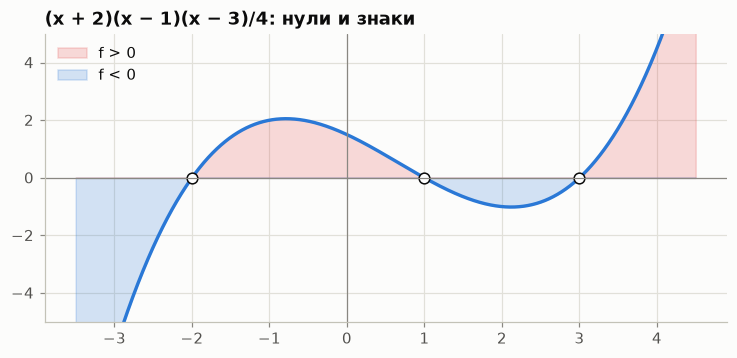

In [13]:
p = lambda x: (x + 2) * (x - 1) * (x - 3) / 4  # noqa: E731
x = np.linspace(-3.5, 4.5, 80001)
y = p(x)
i = np.where(np.sign(y[:-1]) * np.sign(y[1:]) <= 0)[0]
print("нули ≈", np.unique(x[i].round(3)), "| f(0) =", p(0))
print("знаки на участках:", ["+" if p(v) > 0 else "−" for v in (-3, 0, 2, 4)])

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.fill_between(x, 0, np.maximum(y, 0), color=RED, alpha=0.2, label="f > 0")
ax.fill_between(x, 0, np.minimum(y, 0), color=BLUE, alpha=0.2, label="f < 0")
ax.plot(x, y, color=BLUE, lw=2.2)
ax.plot([-2, 1, 3], [0, 0, 0], "o", mfc="white", mec=INK, ms=7)
axes_cross(ax)
ax.set(ylim=(-5, 5), title="(x + 2)(x − 1)(x − 3)/4: нули и знаки")
ax.legend()
plt.show()

## 7. Экстремумы: локальные и глобальные, max и argmax

«Горный маршрут» $-0.05x^4 + 0.9x^2 + 0.3x + 2$ на отрезке $[-4.5; 4.5]$: два локальных максимума,
глобальный минимум — на краю.

max = 6.962  argmax = 3.08
min = -1.628  argmin = -4.5 ← край отрезка
  локальный max: x ≈ -2.913, f ≈ 5.163
  локальный min: x ≈ -0.167, f ≈ 1.975
  локальный max: x ≈ 3.080, f ≈ 6.962
точные критические точки (корни −0.2x³ + 1.8x + 0.3): [-2.913 -0.167  3.08 ]


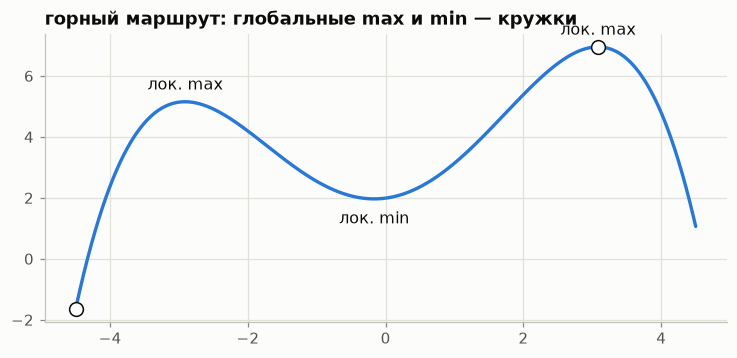

In [14]:
mountain = lambda x: -0.05 * x**4 + 0.9 * x**2 + 0.3 * x + 2  # noqa: E731
x = np.linspace(-4.5, 4.5, 90001)
y = mountain(x)
print("max =", y.max().round(3), " argmax =", x[y.argmax()].round(3))
print("min =", y.min().round(3), " argmin =", x[y.argmin()].round(3), "← край отрезка")
d = np.diff(y)
turn = np.where(np.sign(d[:-1]) != np.sign(d[1:]))[0] + 1
for k in turn:
    print(f"  локальный {'max' if d[k - 1] > 0 else 'min'}: x ≈ {x[k]:.3f}, f ≈ {y[k]:.3f}")
print("точные критические точки (корни −0.2x³ + 1.8x + 0.3):", np.sort(np.roots([-0.2, 0, 1.8, 0.3])).round(3))

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(x, y, color=BLUE, lw=2.2)
for k in turn:
    ax.annotate("лок. max" if d[k - 1] > 0 else "лок. min", (x[k], y[k]), textcoords="offset points",
                xytext=(0, 8 if d[k - 1] > 0 else -16), ha="center")
ax.plot([x[y.argmax()], x[y.argmin()]], [y.max(), y.min()], "o", mfc="white", mec=INK, ms=9)
ax.set_title("горный маршрут: глобальные max и min — кружки")
plt.show()

## 8. Уравнения и неравенства по графику

Когда теплее 17 °C? Решаем $T(t) > 17$ — где график выше горизонтали $y = 17$.

In [15]:
h = np.linspace(0, 24, 24001)
warm = h[T(h) > 17]
print(f"теплее 17 °C: с {warm.min():.2f} до {warm.max():.2f} ч; T(11) = {T(11):.4f}, T(19) = {T(19):.4f}")
F = np.linspace(-6, 6, 12001)
print("наименьшее F на сетке с шагом 0.001, где σ(F) > 0.5:", F[1 / (1 + np.exp(-F)) > 0.5].min().round(3), "→ σ(F) > 0.5 ⇔ F > 0")

теплее 17 °C: с 11.00 до 19.00 ч; T(11) = 17.0000, T(19) = 17.0000
наименьшее F на сетке с шагом 0.001, где σ(F) > 0.5: 0.001 → σ(F) > 0.5 ⇔ F > 0


## 9. Чётность, период, ограниченность, асимптоты

In [16]:
t = np.linspace(0.1, 3, 30)
for name, g in {"x²": lambda x: x**2, "x³": lambda x: x**3, "|x|": np.abs, "x² + x": lambda x: x**2 + x,
                "σ(x) − ½": lambda x: 1 / (1 + np.exp(-x)) - 0.5}.items():
    print(f"{name:9s} чётная: {np.allclose(g(-t), g(t))!s:5s}  нечётная: {np.allclose(g(-t), -g(t))}")
s = np.linspace(-7, 7, 1401)
print("sin(x + 2π) == sin x:", np.allclose(np.sin(s + 2 * np.pi), np.sin(s)))
for R in [10, 100, 1000]:
    print(f"(2x + 1)/(x − 1) при x = {R}: {(2 * R + 1) / (R - 1):.5f}  → асимптота y = 2")

x²        чётная: True   нечётная: False
x³        чётная: False  нечётная: True
|x|       чётная: True   нечётная: False
x² + x    чётная: False  нечётная: False
σ(x) − ½  чётная: False  нечётная: True
sin(x + 2π) == sin x: True
(2x + 1)/(x − 1) при x = 10: 2.33333  → асимптота y = 2
(2x + 1)/(x − 1) при x = 100: 2.03030  → асимптота y = 2
(2x + 1)/(x − 1) при x = 1000: 2.00300  → асимптота y = 2


## 10. Прямая и парабола

Прямая через две точки: $k = \Delta y / \Delta x$, $b = f(0)$. Парабола: вершина $x_0 = -b/(2a)$,
корни по дискриминанту; выделение полного квадрата $x^2 - 4x + 3 = (x - 2)^2 - 1$.

прямая через (0, 1) и (2, 5): y = 2.000·x + 1.000
через (−1, 7) и (2, 1): k = -2.0, b = 5.0
вершина: (2.0, -1.0)  D = 4  корни: [1. 3.]


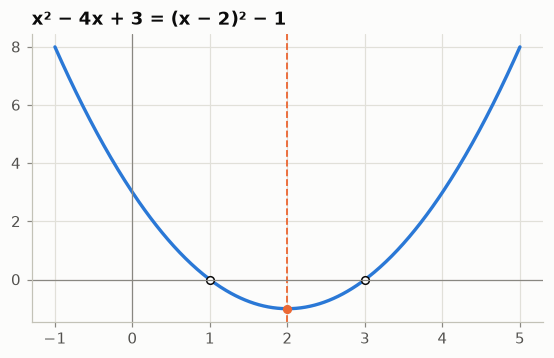

In [17]:
k, b = np.polyfit([0, 2], [1, 5], 1)
print(f"прямая через (0, 1) и (2, 5): y = {k:.3f}·x + {b:.3f}")
k2 = (1 - 7) / (2 - (-1))
print(f"через (−1, 7) и (2, 1): k = {k2}, b = {7 - k2 * (-1)}")

a, bb, c = 1, -4, 3
x0 = -bb / (2 * a)
print("вершина:", (x0, a * x0**2 + bb * x0 + c), " D =", bb**2 - 4 * a * c, " корни:", np.sort(np.roots([a, bb, c])))

x = np.linspace(-1, 5, 400)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(x, x**2 - 4 * x + 3, color=BLUE, lw=2.2)
ax.axvline(2, color=ORANGE, ls="--", lw=1.2)
ax.plot([2], [-1], "o", color=ORANGE)
ax.plot([1, 3], [0, 0], "o", mfc="white", mec=INK)
axes_cross(ax)
ax.set_title("x² − 4x + 3 = (x − 2)² − 1")
plt.show()

## 11. Зоопарк функций

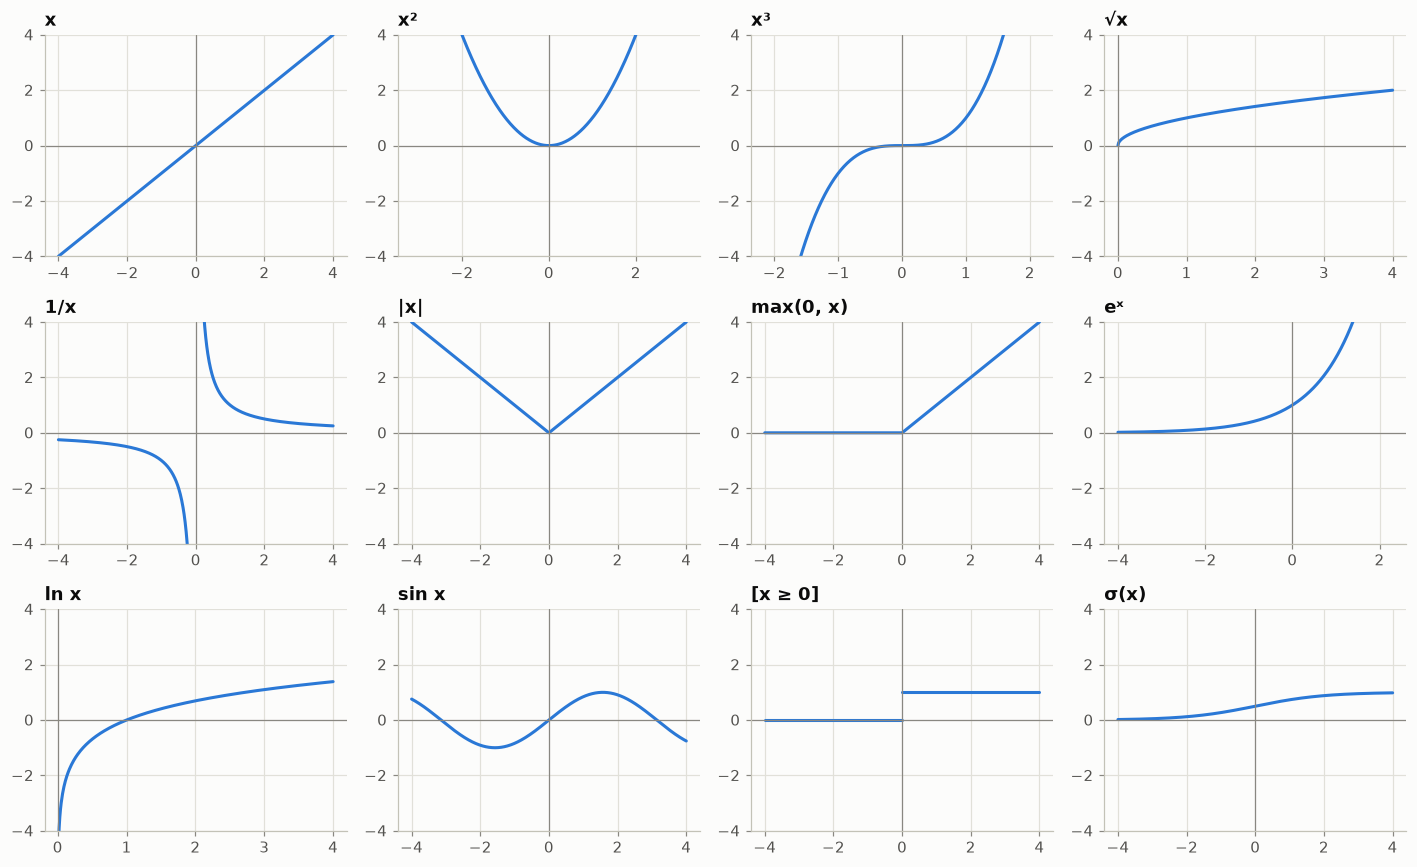

In [18]:
with np.errstate(all="ignore"):
    zoo = {
        "x": lambda x: x, "x²": lambda x: x**2, "x³": lambda x: x**3, "√x": np.sqrt,
        "1/x": lambda x: 1 / x, "|x|": np.abs, "max(0, x)": lambda x: np.maximum(0, x), "eˣ": np.exp, "ln x": np.log,
        "sin x": np.sin, "[x ≥ 0]": lambda x: (x >= 0).astype(float), "σ(x)": lambda x: 1 / (1 + np.exp(-x)),
    }
    x = np.linspace(-4, 4, 801)
    fig, axes = plt.subplots(3, 4, figsize=(13, 8))
    for ax, (name, g) in zip(axes.flat, zoo.items()):
        y = g(x)
        y = np.where(np.abs(y) > 10, np.nan, y)
        if name in ("1/x", "[x ≥ 0]"):
            y[np.r_[False, np.abs(np.diff(y)) > 0.5]] = np.nan
        ax.plot(x, y, color=BLUE, lw=2)
        axes_cross(ax)
        ax.set_title(name)
        ax.set_ylim(-4, 4)
    plt.tight_layout()
    plt.show()

## 12. Сдвиги и растяжения

$y = a \cdot g(k(x - b)) + c$. Сдвиг вправо — это **минус** внутри скобки: у $(x-2)^2$ дно в точке 2.
А в $(2x - 2)^2 = (2(x - 1))^2$ сдвиг только на 1.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


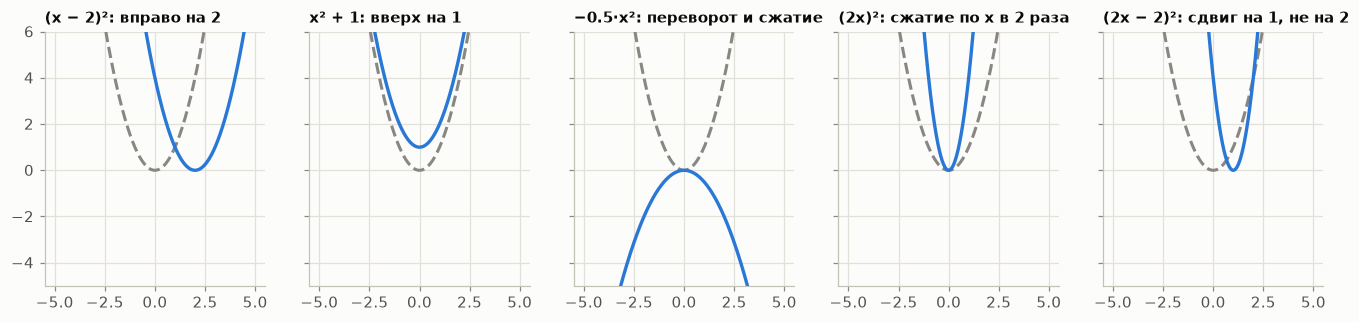

дно (x − 2)²: 2.0 | дно (2x − 2)²: 1.0


In [19]:
g = lambda x: x**2  # noqa: E731
x = np.linspace(-5, 5, 1001)
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for ax, (title, y) in zip(axes, [
    ("(x − 2)²: вправо на 2", g(x - 2)),
    ("x² + 1: вверх на 1", g(x) + 1),
    ("−0.5·x²: переворот и сжатие", -0.5 * g(x)),
    ("(2x)²: сжатие по x в 2 раза", g(2 * x)),
    ("(2x − 2)²: сдвиг на 1, не на 2", g(2 * x - 2)),
]):
    ax.plot(x, g(x), "--", color=MUTED, label="x²")
    ax.plot(x, y, color=BLUE, lw=2.2)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-5, 6)
plt.show()
print("дно (x − 2)²:", x[np.argmin(g(x - 2))].round(2), "| дно (2x − 2)²:", x[np.argmin(g(2 * x - 2))].round(2))

Поиграйте сами (в запущенном Jupyter появятся ползунки):

In [20]:
try:
    from ipywidgets import FloatSlider, interact

    def show(a=1.0, b=0.0, c=0.0, k=1.0):
        fig, ax = plt.subplots(figsize=(6, 3.4))
        ax.plot(x, g(x), "--", color=MUTED)
        ax.plot(x, a * g(k * (x - b)) + c, color=BLUE, lw=2.2)
        ax.set(ylim=(-5, 5), title=f"y = {a}·(({k})(x − {b}))² + {c}")
        plt.show()

    interact(show, a=FloatSlider(value=1, min=-3, max=3, step=0.25), b=FloatSlider(value=0, min=-3, max=3, step=0.25),
             c=FloatSlider(value=0, min=-3, max=3, step=0.25), k=FloatSlider(value=1, min=0.25, max=3, step=0.25))
except ImportError:
    print("ipywidgets не установлен: pip install ipywidgets")

interactive(children=(FloatSlider(value=1.0, description='a', max=3.0, min=-3.0, step=0.25), FloatSlider(value…

## 13. Кусочные функции

Разные формулы на разных участках: `np.where`, `np.select`, `np.piecewise`. Дерево решений —
кусочно-постоянная функция, потери Хьюбера — склейка параболы и прямых.

Хьюбер непрерывен в ±1: True | тариф: f(2) = 150  f(5) = 240


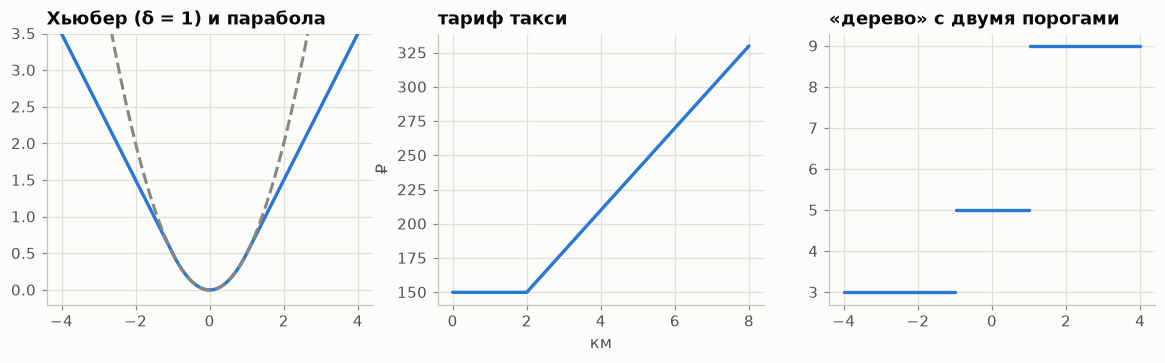

In [21]:
x = np.linspace(-4, 4, 801)
huber = np.where(np.abs(x) <= 1, 0.5 * x**2, np.abs(x) - 0.5)
tariff = lambda km: np.where(km <= 2, 150, 150 + 30 * (km - 2))  # noqa: E731
step3 = np.select([x <= -1, x <= 1], [3, 5], default=9)
print("Хьюбер непрерывен в ±1:", 0.5 * 1**2 == abs(1) - 0.5, "| тариф: f(2) =", tariff(2), " f(5) =", tariff(5))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(x, huber, color=BLUE, lw=2.2)
axes[0].plot(x, 0.5 * x**2, "--", color=MUTED)
axes[0].set(ylim=(-0.2, 3.5), title="Хьюбер (δ = 1) и парабола")
km = np.linspace(0, 8, 400)
axes[1].plot(km, tariff(km), color=BLUE, lw=2.2)
axes[1].set(title="тариф такси", xlabel="км", ylabel="₽")
y3 = step3.astype(float)
y3[np.r_[False, np.diff(y3) != 0]] = np.nan
axes[2].plot(x, y3, color=BLUE, lw=2.2)
axes[2].set(title="«дерево» с двумя порогами")
plt.show()

## 14. Сумма функций — и бустинг как сумма ступенек

$(f + g)(x) = f(x) + g(x)$ — высоты складываются в каждой точке. Модель бустинга:
$F_M = F_0 + \nu h_1 + \dots + \nu h_M$, где $h_m$ — ступенька, обученная на остатках.

m =  1: MSE = 0.4089
m =  3: MSE = 0.2986
m = 10: MSE = 0.1498
m = 30: MSE = 0.0580


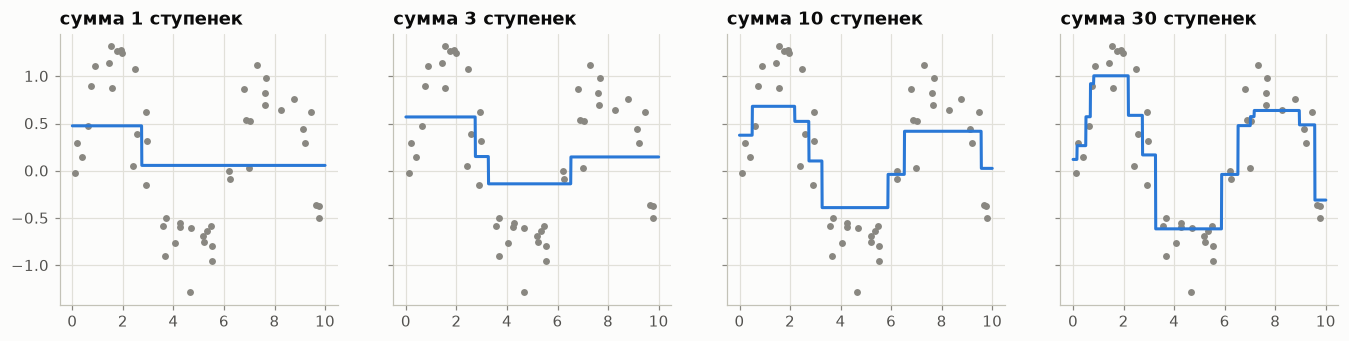

In [22]:
X, y = datasets.regression_1d(kind="sine", n=50, noise=0.25, seed=7)
x = X[:, 0]
grid = np.linspace(0, 10, 1001)
nu = 0.5
F, Fg = np.full_like(y, y.mean()), np.full_like(grid, y.mean())
snapshots = {}
for m in range(1, 31):
    r = y - F
    best = None
    for t in (x[1:] + x[:-1]) / 2:
        L, R = r[x <= t], r[x > t]
        if len(L) and len(R):
            sse = ((L - L.mean())**2).sum() + ((R - R.mean())**2).sum()
            if best is None or sse < best[0]:
                best = (sse, t, L.mean(), R.mean())
    _, t, lv, rv = best
    F = F + nu * np.where(x <= t, lv, rv)
    Fg = Fg + nu * np.where(grid <= t, lv, rv)
    if m in (1, 3, 10, 30):
        snapshots[m] = Fg.copy()
        print(f"m = {m:2d}: MSE = {((y - F)**2).mean():.4f}")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, (m, Fm) in zip(axes, snapshots.items()):
    ax.plot(x, y, "o", color=MUTED, ms=3.5)
    ax.plot(grid, Fm, color=BLUE, lw=2)
    ax.set_title(f"сумма {m} ступенек")
plt.show()

## 15. Композиция и обратная функция

$g(h(x))$: сначала внутренняя, потом внешняя. Порядок важен. Обратная к сигмоиде — логит
$\ln\frac{p}{1-p}$; с него стартует бустинг-классификатор.

g(h(2)) = 9  h(g(2)) = 5
прогноз F = -2 → вероятность σ(F) = 0.119
прогноз F =  0 → вероятность σ(F) = 0.500
прогноз F =  2 → вероятность σ(F) = 0.881
logit(σ(z)) == z: True | F0 при доле 0.3: -0.8473


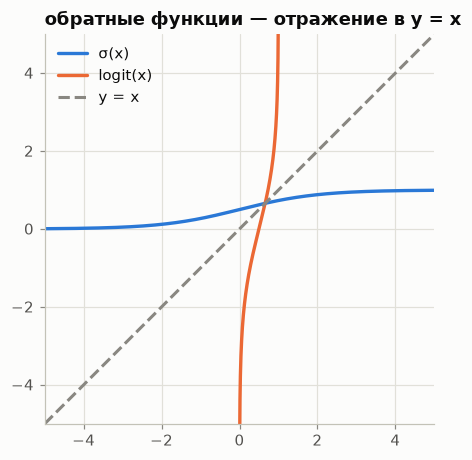

In [23]:
h = lambda x: x + 1  # noqa: E731
g2 = lambda u: u**2  # noqa: E731
print("g(h(2)) =", g2(h(2)), " h(g(2)) =", h(g2(2)))

sigmoid = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
logit = lambda p: np.log(p / (1 - p))  # noqa: E731
for F0 in (-2, 0, 2):
    print(f"прогноз F = {F0:2d} → вероятность σ(F) = {sigmoid(F0):.3f}")
z = np.linspace(-5, 5, 101)
print("logit(σ(z)) == z:", np.allclose(logit(sigmoid(z)), z), "| F0 при доле 0.3:", round(logit(0.3), 4))

fig, ax = plt.subplots(figsize=(4.6, 4.6))
zz = np.linspace(-5, 5, 400)
pp = np.linspace(0.005, 0.995, 400)
ax.plot(zz, sigmoid(zz), color=BLUE, lw=2.2, label="σ(x)")
ax.plot(pp, logit(pp), color=ORANGE, lw=2.2, label="logit(x)")
ax.plot([-5, 5], [-5, 5], "--", color=MUTED, label="y = x")
ax.set(xlim=(-5, 5), ylim=(-5, 5), aspect="equal", title="обратные функции — отражение в y = x")
ax.legend()
plt.show()

## 16. Функции двух переменных

Цена $P(s, d) = 2 + 0.1s - 0.15d$: карта высот и срез при фиксированном $d$.

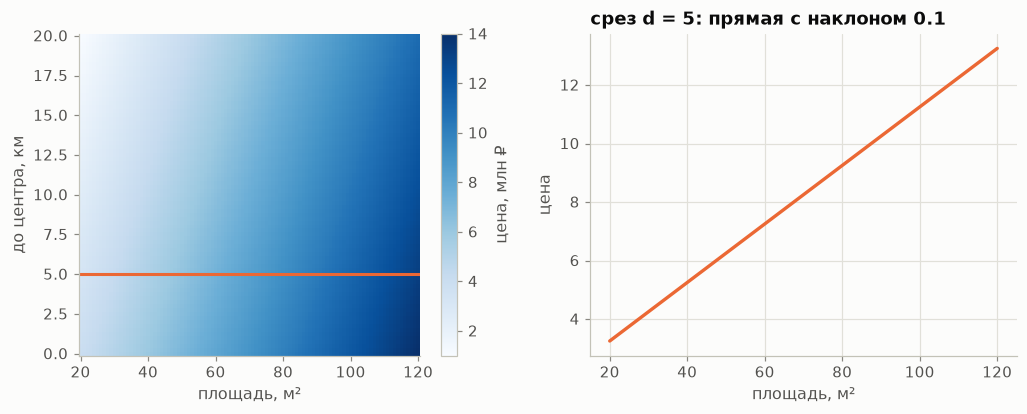

In [24]:
s, d = np.meshgrid(np.linspace(20, 120, 101), np.linspace(0, 20, 81))
P = 2 + 0.1 * s - 0.15 * d
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
im = a1.pcolormesh(s, d, P, cmap="Blues", shading="auto")
a1.axhline(5, color=ORANGE, lw=2)
fig.colorbar(im, ax=a1, label="цена, млн ₽")
a1.set(xlabel="площадь, м²", ylabel="до центра, км")
row = np.abs(d[:, 0] - 5).argmin()
a2.plot(s[row], P[row], color=ORANGE, lw=2.2)
a2.set(xlabel="площадь, м²", ylabel="цена", title="срез d = 5: прямая с наклоном 0.1")
plt.show()

## 17. Модель и потери — функции

Пень «площадь ≤ 3.5?» на шести квартирах: листья — средние цен слева и справа. Потери модели-константы
$L(c)$ — парабола с дном в среднем 6; абсолютные потери — ломаная с плоским дном на $[4; 7]$.

листья: 3.0 9.0 | F(2.5) = 3.0  F(5) = 9.0
MSE: argmin = 6.0  min = 10.6667  коэффициенты: [  1.    -12.     46.667]
MAE: min = 3.0  на отрезке [ 4.0 ; 7.0 ]


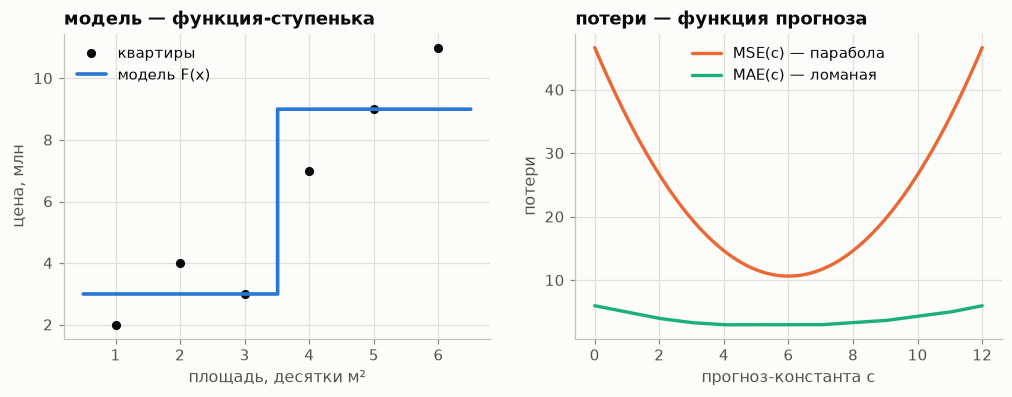

In [25]:
X6, y6 = datasets.toy_regression()
x6 = X6[:, 0]
left, right = y6[x6 <= 3.5].mean(), y6[x6 > 3.5].mean()
model = lambda v: np.where(v <= 3.5, left, right)  # noqa: E731
print("листья:", left, right, "| F(2.5) =", model(2.5), " F(5) =", model(5))

c = np.linspace(0, 12, 1201)
mse = ((y6[:, None] - c)**2).mean(axis=0)
mae = np.abs(y6[:, None] - c).mean(axis=0)
print("MSE: argmin =", c[mse.argmin()], " min =", mse.min().round(4), " коэффициенты:", np.polyfit(c, mse, 2).round(3))
flat = c[np.isclose(mae, mae.min())]
print("MAE: min =", mae.min().round(4), " на отрезке [", flat.min(), ";", flat.max(), "]")

grid = np.linspace(0.5, 6.5, 601)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(x6, y6, "o", color=INK, label="квартиры")
a1.step(grid, model(grid), where="post", color=BLUE, lw=2.4, label="модель F(x)")
a1.set(xlabel="площадь, десятки м²", ylabel="цена, млн", title="модель — функция-ступенька")
a1.legend()
a2.plot(c, mse, color=ORANGE, lw=2.2, label="MSE(c) — парабола")
a2.plot(c, mae, color=AQUA, lw=2.2, label="MAE(c) — ломаная")
a2.set(xlabel="прогноз-константа c", ylabel="потери", title="потери — функция прогноза")
a2.legend()
plt.show()

## 18. Масштаб осей

Та же кривая ошибки $5 \cdot 0.9^m + 0.05$ на обычной и логарифмической шкале.

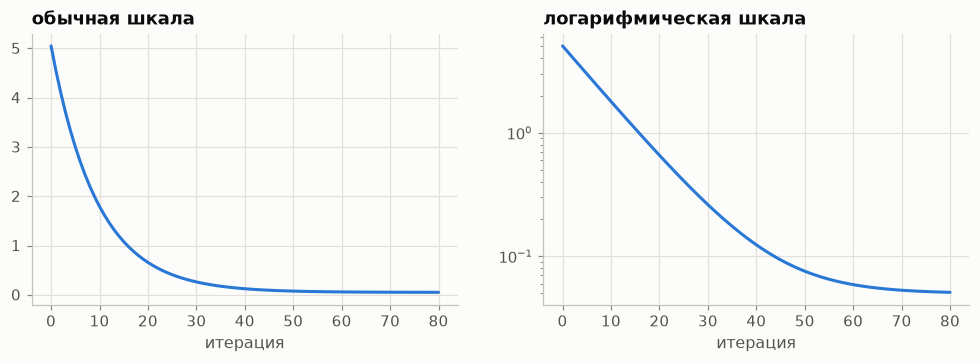

ошибка выходит на полку около итерации 43


In [26]:
m = np.arange(81)
err = 5 * 0.9**m + 0.05
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.plot(m, err, color=BLUE)
a1.set(title="обычная шкала", xlabel="итерация")
a2.semilogy(m, err, color=BLUE)
a2.set(title="логарифмическая шкала", xlabel="итерация")
plt.show()
print("ошибка выходит на полку около итерации", int(np.log(0.01) / np.log(0.9)))

## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ Функция цены квартиры $P(s) = 1.5 + 0.12s$: цена 50 м² и площадь за 9 млн.
2. ★☆☆ Найдите $f(a+1)$ для $f(x) = x^2 - 3x$ и проверьте подстановкой.
3. ★☆☆ Области определения трёх функций — аналитически и по сетке.
4. ★★☆ Постройте $(x-3)^2 - 1$ и найдите его дно и корни численно.
5. ★★☆ Прямая через две точки: наклон, сдвиг, пересечения с осями.
6. ★★☆ Нули и знаки функции; максимум и argmax на отрезке.
7. ★★☆ Проверьте на сетке, что $\sigma(-x) = 1 - \sigma(x)$.
8. ★★☆ Композиция и порядок; обратная к $(x - 1)/3$.
9. ★★★ Лучшая константа для цен $1, 2, 6$ при MSE и MAE.
10. ★★★ Бустинг как сумма ступенек: как MSE зависит от числа ступенек и темпа $\nu$.